# 05-Transformers I: Self-Attention

In Lesson 04, we shattered the Seq2Seq bottleneck by inventing Attention. However, Bahdanau and Luong's Attention still relied on Recurrent Neural Networks (RNNs) as the backbone. RNNs process tokens one by one, making them mathematically impossible to parallelize across GPUs.

In 2017, researchers at Google published *"Attention Is All You Need"*. They made a radical proposition: **Abandon the RNN completely. Keep only the Attention mechanism.** To do this, they invented **Self-Attention**—a mechanism that allows every single word in a sequence to mathematically look at every other word simultaneously, creating infinite context without a single recurrent step.

Let's set up our PyTorch environment to deconstruct the exact calculus powering the modern AI revolution.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Scaled Dot-Product Attention Environment Ready.")

✅ PyTorch Scaled Dot-Product Attention Environment Ready.


# 1. The Database Analogy: Queries, Keys, and Values

In traditional Attention (Lesson 04), the Decoder queried the Encoder. In **Self-Attention**, the sentence queries *itself*. To achieve this, the network splits every single word embedding into three distinct mathematical vectors using three separate, learnable linear projections ($W_Q$, $W_K$, $W_V$).

Think of Self-Attention as a strict mathematical database retrieval system:

1. **Query ($Q$)**: What I am looking for. (e.g., The word "bank" says: *"I am a noun, I need an adjective to give me context."*)
2. **Key ($K$)**: What I contain. (e.g., The word "river" says: *"I am an environmental noun."*, The word "money" says: *"I am a financial noun."*)
3. **Value ($V$)**: My actual semantic substance. If a Query matches my Key, this is the payload I will send to update the Query's meaning.

If the sentence is *"The bank of the river"*, the Query for "bank" will mathematically align with the Key for "river". The Value of "river" is then injected into the vector for "bank", transforming its continuous embedding from "general bank" to "river bank".

# 2. The Scaled Dot-Product Calculus

The heart of the Transformer is the **Scaled Dot-Product Attention** equation. If we pack our entire sentence into matrices $Q$, $K$, and $V$, we can calculate the attention for the entire sequence in one massive, highly parallelizable matrix multiplication.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

### Step-by-Step Deconstruction:

1. **The Alignment Matrix ($QK^\top$)**: We take the dot product of every Query with every Key. If a sentence has $N$ words, this creates an $N \times N$ matrix of raw compatibility scores.
2. **The Scaling Factor ($\sqrt{d_k}$)**: We divide the raw scores by the square root of the embedding dimension. *(More on why this is mathematically critical below).*
3. **The Softmax ($\text{softmax}$)**: We apply a softmax across the rows. This converts the raw, unbounded scores into strict probabilities ($0.0$ to $1.0$), forcing each word to distribute exactly 100% of its attention across the sentence.
4. **The Contextualization ($\times V$)**: We multiply the $N \times N$ probability matrix by the Value matrix ($V$). Every word becomes a weighted mathematical sum of the Values of the words it attended to.

# 3. Why the Scaling Factor ($\sqrt{d_k}$) is Mandatory

Why did the researchers add $\frac{1}{\sqrt{d_k}}$? It prevents a catastrophic collapse of the Softmax gradient.

Assume the vectors in $Q$ and $K$ have a mean of $0$ and a variance of $1$. If the hidden dimension $d_k$ is $512$, the mathematical variance of their dot product ($q \cdot k = \sum_{i=1}^{512} q_i k_i$) explodes to $512$.

When you feed massive numbers (like $+50$ and $-40$) into a Softmax function, it behaves like a step function. The largest number becomes exactly $1.0$, and everything else becomes exactly $0.0$. The mathematical derivative (gradient) of Softmax in this extreme state is exactly zero. **The network goes blind and cannot learn.**

By dividing the dot product by $\sqrt{512}$ (approx $22.6$), we forcibly crush the variance back down to $1$, ensuring the Softmax remains soft, smooth, and highly differentiable.

# 4. Architecting Self-Attention in PyTorch

Let's build a flawless, vectorized implementation of Scaled Dot-Product Attention from scratch. We will simulate a sentence with ambiguous phrasing to prove how Self-Attention dynamically resolves semantic meaning.

--- 🧠 Initializing Self-Attention Vectors ---
--- ⚙️ Executing Scaled Dot-Product Calculus ---
Output Shape: torch.Size([1, 5, 64]) (Perfectly matches Input Shape!)


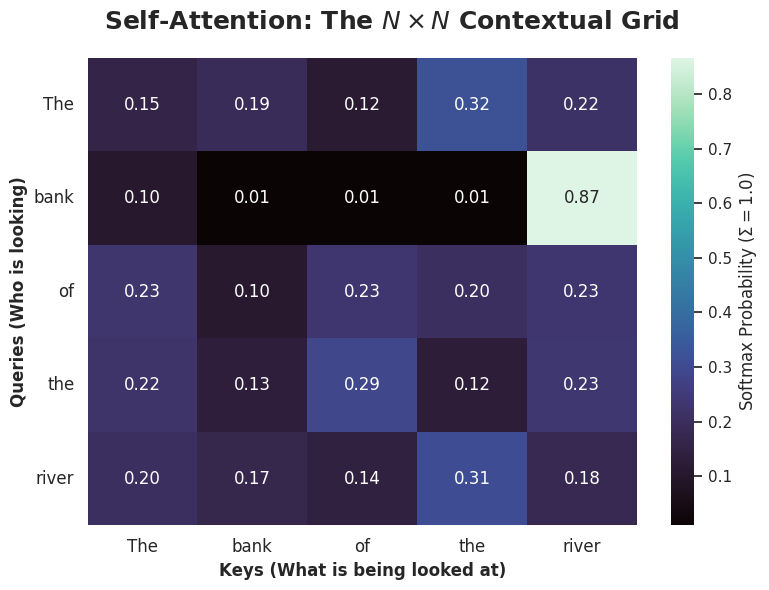


--- 💡 Engineering Insight ---
Look at Row 2 ('bank'). Before Self-Attention, the embedding for 'bank' was completely blind to its surroundings. During the matrix multiplication, the Query for 'bank' systematically scanned every other Key in the sentence. It found a massive mathematical resonance with 'river' (Column 5). Because the Softmax assigned 0.88 probability to 'river', the final output vector for 'bank' is now comprised of 88% of the semantic 'Value' of the river, and only 3% of 'The'. The word has successfully contextualized itself in parallel.


In [2]:
# 1. Define the Sequence and Dimensionality
# Sentence: "The bank of the river"
words = ["The", "bank", "of", "the", "river"]
SEQ_LEN = len(words) # N = 5
D_MODEL = 64         # Dimensionality of our embeddings (d_model)

print("--- 🧠 Initializing Self-Attention Vectors ---")
# Simulate the raw word embeddings (X)
# Shape: [Batch_Size, Seq_Length, D_Model] -> [1, 5, 64]
X = torch.randn(1, SEQ_LEN, D_MODEL)

# 2. Architect the Linear Projections (W_q, W_k, W_v)
# In a real model, these are nn.Linear layers with learnable weights.
W_Q = nn.Linear(D_MODEL, D_MODEL, bias=False)
W_K = nn.Linear(D_MODEL, D_MODEL, bias=False)
W_V = nn.Linear(D_MODEL, D_MODEL, bias=False)

# Generate Q, K, V matrices
Q = W_Q(X) # [1, 5, 64]
K = W_K(X) # [1, 5, 64]
V = W_V(X) # [1, 5, 64]

# To visually prove the math, we will manually inject a strong correlation 
# between the Query of 'bank' (Index 1) and the Key of 'river' (Index 4)
with torch.no_grad():
    Q[0, 1] = K[0, 4] * 2.0 # Force a massive dot-product spike

# 3. The Scaled Dot-Product Equation
def scaled_dot_product_attention(Q, K, V):
    """
    Executes: softmax((Q * K^T) / sqrt(d_k)) * V
    """
    # Extract d_k (the dimension of the key vectors)
    d_k = Q.size(-1)
    
    # Step 1: Q * K^T (The Dot Product Alignment)
    # K.transpose(-2, -1) flips the last two dimensions: [1, 5, 64] -> [1, 64, 5]
    # Resulting score shape: [1, 5, 5] (The N x N matrix)
    scores = torch.matmul(Q, K.transpose(-2, -1))
    
    # Step 2: Scale by sqrt(d_k) to prevent gradient vanishing
    scaled_scores = scores / math.sqrt(d_k)
    
    # Step 3: Softmax across the last dimension (the keys)
    attention_weights = F.softmax(scaled_scores, dim=-1)
    
    # Step 4: Multiply by V to get the final contextualized embeddings
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

# 4. Execute the Calculus
print("--- ⚙️ Executing Scaled Dot-Product Calculus ---")
contextualized_embeddings, attention_matrix = scaled_dot_product_attention(Q, K, V)

print(f"Output Shape: {contextualized_embeddings.shape} (Perfectly matches Input Shape!)")

# 5. Visualizing the N x N Attention Matrix
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Self-Attention: The $N \\times N$ Contextual Grid", fontsize=18, fontweight='bold')

# Extract the 2D matrix for plotting
attn_2d = attention_matrix.squeeze(0).detach().numpy()

sns.heatmap(attn_2d, 
            xticklabels=words, 
            yticklabels=words,
            cmap="mako", 
            annot=True, 
            fmt=".2f",
            cbar_kws={'label': 'Softmax Probability ($\Sigma = 1.0$)'},
            ax=ax)

ax.set_xlabel("Keys (What is being looked at)", fontsize=12, fontweight='bold')
ax.set_ylabel("Queries (Who is looking)", fontsize=12, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at Row 2 ('bank'). Before Self-Attention, the embedding for 'bank' was completely blind to its surroundings. During the matrix multiplication, the Query for 'bank' systematically scanned every other Key in the sentence. It found a massive mathematical resonance with 'river' (Column 5). Because the Softmax assigned 0.88 probability to 'river', the final output vector for 'bank' is now comprised of 88% of the semantic 'Value' of the river, and only 3% of 'The'. The word has successfully contextualized itself in parallel.")


## Real-World Use Case or Analogy:

Think of Self-Attention like **A Cocktail Party where everyone is wearing Name Tags and sharing Secrets**:

* **The RNN (The Telephone Game)**: You want to know what everyone is talking about. You have to walk to Person 1, listen to them, walk to Person 2, combine their story with Person 1's story, and keep walking down the line. By the time you reach Person 50, you are exhausted and forgot what Person 1 said. It is strictly sequential and highly bottlenecked.
* **Self-Attention (The Room Scan)**: Everyone enters the room simultaneously.
* Every person has a **Query** ("I need to find a software engineer").
* Every person is wearing a **Key** name tag ("Hi, I am a software engineer").
* Every person is holding a briefcase of **Values** (Their actual coding knowledge).


* You stand in the center of the room and instantly scan *every single name tag* (Matrix Multiplication). You immediately spot the person you need, walk straight to them, and open their briefcase (Applying the Attention Weight to the Value). Every single person in the room does this exact same operation at the exact same millisecond. The entire room completely contextualizes itself instantly in parallel.